## Self Supervised Model Pretraining

This notebook pretrains the SSL encoder only on 70% benign training windows. 

Input window: **32 messages** 

Features: 

- **CAN_ID**: categorical embedding 
- **b0-b7, DLC, Δt**: numeric features
- **Δt** is log transformed before standarization 

30% of the message positions will be masked and reconstructed. 

The other 30% of the test windows will not be used for SSL training, and will be used later for the XGBoost evaluation pipeline. 


In [33]:
import math 
import random 
import numpy as np 
import time 
from pathlib import Path 

import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader, ConcatDataset 
from tqdm import tqdm

In [2]:
SEED = 42 
random.seed(SEED)
torch.manual_seed(SEED)

WINDOW_SIZE = 32 
MASK_PROPORTION = 0.30 

BATCH_SIZE = 128 
NUM_EPOCHS = 15 
LEARNING_RATE = 0.0003 

CAN_EMBEDDING_DIM = 8 
HIDDEN_DIM = 64 

DT_SCALE = 1_000_000.0  #converts from seconds to microseconds 

In [3]:
BENIGN_WINDOWS = Path("..") / "Benign_windows"
ATTACK_WINDOWS = Path("..") / "Attack_windows"
MODEL_FOLDER = Path("..") / "models"

device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")

print("Device:", device)

Device: mps


### Loading the Benign Training Windows 

In [4]:
train_files = sorted(BENIGN_WINDOWS.glob("*_train.pt"))
test_files = sorted(BENIGN_WINDOWS.glob("*_test.pt"))

train_windows = []

for pt_file in train_files: 
    data = torch.load(pt_file, map_location="cpu", weights_only=False)
    train_windows.append(data["features"])
    
print("Training Files:", len(train_files))
print("Test Files:", len(test_files))
print("First Training Tensor:", train_windows[0].shape)

Training Files: 3
Test Files: 3
First Training Tensor: torch.Size([429074, 32, 11])


### CAN ID Vocabulary 

CAN ID needs to be treated as a category and not as a continuous number, since they represent identifiers and the model can get confused if one CAN ID is 700 and the other 800, it might think CAN ID 700 < 800 which its not the correct representation. 

INPUT TOKENS

Tokens are used as placeholders to represent special situations that are not regular CAN IDs.
For example, sometimes a CAN ID might be missing, hidden (for masking).  
Instead of using a default value like 0 which could be confused with a real CAN ID
we use special tokens. 

Allowing the embedding layer to learn a distinct representation for each situation.
This helps the model avoid confusion and improves its understanding of the data.

- MASK_ID: MASK ID token, represents the hidden CAN ID that will be used on the masking during SSL training. 

- UNK_ID: for CAN IDs not seen during benign SSL training 

In [5]:
known_can_ids = set()

for tensor in train_windows:
    ids_in_file = torch.unique(tensor[:, :, 0].long()).tolist()

    for can_id in ids_in_file:
        known_can_ids.add(int(can_id))

known_can_ids = sorted(known_can_ids)

can_id_to_index = {}

for index, can_id in enumerate(known_can_ids):
    can_id_to_index[can_id] = index

NUM_CAN_IDS = len(known_can_ids)
UNK_ID = NUM_CAN_IDS
MASK_ID = NUM_CAN_IDS + 1

print("Known benign CAN IDs:", NUM_CAN_IDS)
print("UNK_ID:", UNK_ID)
print("MASK_ID:", MASK_ID)

Known benign CAN IDs: 56
UNK_ID: 56
MASK_ID: 57


- 56 Unique CAN IDs, which are mapped internally to embedding indexes. 
- UNK_ID 56, used only for any CAN ID not present in the benign training vocabulary. 
- MASK_ID 57, used only during SSL masking, when a CAN ID is intetionally hidden as part of the 30% masking task, its embedding is replaced with 57.

CAN ID is processed separately because it represents a categorical identity and will use an embedding layer. The remaining 10 features (b0-b7, DLC, and Δt) are numerical features. These are preprocessed and standardized before being combined with the CAN-ID embedding and passed to the SSL encoder.

### Numeric Preprocessing Features

- **Payload bytes b0-b7**
- **DLC: Data Length of the Payload**
- **Δt Inter Arrival time**  Contains a lot of variation inside the data, meaning that it can affect the mean and standard deviation, so we compress this large range using a logarithm, converting the seconds to microseconds. 

Logarithmic transformation works well on very small timing values. 

Each feature has its own scale: 

Bytes = 0 to 255
DLC = around 0 to 8 
Δt = around 1e-6 to 0.001 seconds 

These numerical features are standardized before entering the model because they have very different value ranges. standardisation places them on comparable scales so that features with larger numerical values, such as payload bytes, do not dominate smaller features such as timing. 

Using the Z-score formula. 

In [6]:
# Transform Δt 

def transform_delta(delta): 
    delta = delta.float()
    
    delta_microseconds = delta * DT_SCALE
    
    transformed_delta = torch.log1p(delta_microseconds)
    
    return transformed_delta

In [7]:
# Training Statistics 

# Store the total sum of each feature across all the training windows 
# to calculate the mean
feature_sum = torch.zeros(10, dtype=torch.float64)
# Store the total sum of squared values, to calculate the variance and std
feature_squared_sum = torch.zeros(10, dtype=torch.float64)

# Message rows 
number_messages= 0 

# Process 20,000 windows at a time to avoid creating 
# large temporary tensors in memory 
CHUNK_SIZE = 20_000

for training_file in train_windows:
    for start in range(0, len(training_file), CHUNK_SIZE): 
        window_chunk = training_file[start:start + CHUNK_SIZE]
        
        # Remove CAN ID from the feature tensor 
        features = window_chunk[:, :, 1:].float().clone()
        
        # Transform the Δt column 
        features[:, :, -1] = transform_delta(features[:, :, -1])
        
        # Put all messages into rows:
        # (windows, 32, 10) -> (all messages, 10)
        feature_rows = features.reshape(-1, 10)
        
        # Use float64 while calculating statistics over millions of values.
        float64_features = feature_rows.double()
    
        feature_sum += float64_features.sum(dim=0)
        feature_squared_sum += (float64_features ** 2).sum(dim=0)
        
        number_messages += len(feature_rows)

In [8]:
# Calculate the mean and standard deviation of the training data

training_mean = feature_sum / number_messages

training_variance = (feature_squared_sum / number_messages) - (training_mean ** 2)

training_std = torch.sqrt(training_variance) 

# convert to float32 to avoid precision issues 
training_mean = training_mean.float()
training_std = training_std.float()

In [9]:
feature_names = [
    "b0", "b1", "b2", "b3",
    "b4", "b5", "b6", "b7",
    "DLC", "log_dt"
]

for i in range(len(feature_names)):

    print(
        feature_names[i],
        "| mean:", round(training_mean[i].item(), 4),
        "| std:", round(training_std[i].item(), 4)
    )

b0 | mean: 58.0659 | std: 77.6297
b1 | mean: 60.4033 | std: 77.4116
b2 | mean: 48.1177 | std: 72.989
b3 | mean: 61.4968 | std: 84.7441
b4 | mean: 47.9577 | std: 78.4898
b5 | mean: 53.5674 | std: 83.4639
b6 | mean: 33.8867 | std: 63.0744
b7 | mean: 53.2536 | std: 72.7697
DLC | mean: 7.303 | std: 1.4544
log_dt | mean: 2.6932 | std: 2.9822


b0-b7
- different means and variations
- expected because each payload position behaves differently

DLC
- centered near 7–8
- consistent with CAN traffic

log_dt
- no longer an extremely tiny raw number
- transformed into a scale suitable for later standardisation

### CAN ID Index Mapping 

- CAN ID must be separated because it goes to the embedding.
- Δt must receive the same transformation used when we calculated the statistics.
- The 10 numerical features must then be standardized using the training_mean and training_std we already calculated.


In [9]:
def convert_can_ids(raw_can_ids):
    # Convert CAN IDs to embedding indexes 
    can_id_indexes = []
    
    # Get the index of the CAN ID in the training vocabulary 
    for can_id in raw_can_ids.tolist():
        # If the CAN ID is not in the training vocabulary, use UNK_ID
        index = can_id_to_index.get(can_id, UNK_ID)
        can_id_indexes.append(index)
        
    # torch.long is used to store the indexes as integers 
    return torch.tensor(can_id_indexes, dtype=torch.long)

### Standarisation of the features 

We actually prepare the 10 numerical features of one (32,11) CAN window before giving it to the SSL model. Each of the 10 features is standardized using the previously calculated training_mean and training_std, which places the different feature types on comparable numerical scales while keeping the original patterns and differences between messages.

In [10]:
def standardise_features(window):
    
    features = window[:, 1:].float().clone()
    
    # Apply the same transformation established earlier 
    features[:, -1] = transform_delta(features[:, -1])
    
    # Standarize the features
    standardised_features = (features - training_mean) / training_std 
    
    return standardised_features
    

- CAN-ID indexes
Represented as integers / torch.long, because the embedding layer requires integer indexes. 


- b0-b7, DLC, Δt
Represented as decimal numbers / torch.float32

### Training Dataset

The purpose of the Dataset is to automatically apply the CAN ID embeddings and the feature transformations whenever we process a window. 

In [11]:
class BenignWindowDataset(Dataset): 
    
    def __init__(self, windows): 
        self.windows = windows
        
    def __len__(self): 
        return len(self.windows)
    
    def __getitem__(self, index): 
        
        window = self.windows[index]
        
        # Parse the CAN ID column 
        raw_can_ids = window[:, 0].long()
        # Convert CAN IDs to embedding indexes 
        can_id_indexes = convert_can_ids(raw_can_ids)
        
        # Prepare the 10 numerical features for that window 
        standardised_features = standardise_features(window)
        
        # Return the CAN ID indexes and the standardised features 
        return can_id_indexes, standardised_features        

can_id_indexes and standardised_features are the two inputs that we will use for the model. 

### DataSet for the training files

In [12]:
training_datasets = []

for file_windows in train_windows:
    file_dataset = BenignWindowDataset(file_windows)
    training_datasets.append(file_dataset)

# Combine all the datasets into one, helps with memory 
train_dataset = ConcatDataset(training_datasets)

In [13]:
sample_can_ids, sample_features = train_dataset[0]

print("CAN ID indexes:",sample_can_ids.shape)

print("Standardised features:",sample_features.shape)

print("Total training windows:", len(train_dataset))

CAN ID indexes: torch.Size([32])
Standardised features: torch.Size([32, 10])
Total training windows: 1335237


The dataset succesfully prepares each training window while preserving its original 32 message structure. 

For each window we expect 32 CAN messages converted into categorical embedding indexes, plus the 10 processed numerical features. 

We have a total of 1,335,237 training windows across the thee benign training datasets. Which is treated as one whole training dataset without changing the structure of the individual windows. 

### DataLoader 

The dataloader groups the prepared dataset windows into batches for the model training. With a batch of size 128, each batch should contain 128 complete windows, with 32 CAN ID indexes and 32 sets of 10 numerical features per window. 


The DataLoader will shuffle the order in which the windows are selected during training, however it does not change the order of the 32 messages inside each window. 

In [14]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

In [15]:
can_id_batch, feature_batch = next(iter(train_loader))

print("CAN ID batch:",can_id_batch.shape)

print("Feature batch:", feature_batch.shape)

CAN ID batch: torch.Size([128, 32])
Feature batch: torch.Size([128, 32, 10])


### Masking 30% 

Self supervised learning objective of this project is to deliberately hide parts of each benign CAN window and ask the model to reconstruct the missing information. In order to do this approximately 30% of the 32 message positions in every window are randomly selected for masking. 

Since a window contains 32 messages, 10 message positions are masked, corresponding to the 30%. The masked positions change randomly during training so that the model learns relationships across the full CAN sequence rather than memorising fixed positions. 

The model must use the surrounding sequence context to reconstruct information from the 10 hidden positions. 

CAN ID = MASK_ID

numerical features = hidden representation

#### Create an empty mask

In [17]:
windows_in_batch = can_id_batch.shape[0]
window_size = can_id_batch.shape[1]

positions_to_mask = round(window_size* MASK_PROPORTION)

window_mask = torch.zeros(windows_in_batch, 
                              window_size, 
                              # Boolean mask 
                              dtype=torch.bool, 
                              device=device)

print("Window mask shape:", window_mask.shape)
print("First window mask:")
print(window_mask[0])


Window mask shape: torch.Size([128, 32])
First window mask:
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False], device='mps:0')


Create an empty boolean mask which we will populate with 10 random positions to turn into True. 

#### Choose the random positions

In [18]:
for window_index in range(windows_in_batch):
    random_positions = torch.randperm(window_size, device=device)[:positions_to_mask]
    window_mask[window_index, random_positions] = True 

print("Window mask shape:", window_mask.shape)
print("First window mask:")
print(window_mask[0])
print("\n Masked positions:", torch.where(window_mask[0])[0])

Window mask shape: torch.Size([128, 32])
First window mask:
tensor([ True,  True, False, False, False,  True, False, False, False,  True,
         True, False, False, False,  True,  True, False, False, False, False,
        False, False,  True, False, False, False, False,  True, False,  True,
        False, False], device='mps:0')

 Masked positions: tensor([ 0,  1,  5,  9, 10, 14, 15, 22, 27, 29], device='mps:0')


#### Apply the mask to the CAN IDs 

In [20]:
masked_can_ids = can_id_batch.clone() 

In [21]:
masked_can_ids[window_mask] = MASK_ID

print("Original CAN ID indexes:")
print(can_id_batch[0])

print("\nMasked CAN ID indexes:")
print(masked_can_ids[0])

print("\nMASK_ID:", MASK_ID)

Original CAN ID indexes:
tensor([16, 20,  9, 21, 24,  1,  2, 27,  8,  7, 48, 10, 11,  3,  4,  5,  6, 26,
        31, 36,  9, 32,  1,  2, 12,  7,  8, 10, 11, 23, 41,  3])

Masked CAN ID indexes:
tensor([57, 57,  9, 21, 24, 57,  2, 27,  8, 57, 57, 10, 11,  3, 57, 57,  6, 26,
        31, 36,  9, 32, 57,  2, 12,  7,  8, 57, 11, 57, 41,  3])

MASK_ID: 57


#### Apply masking to the Numeric Features

CAN ID = MASK_ID

b0-b7, DLC, Δt = all 0

Because the numerical features have already been standardised, 0 represents approximately the centre/average value of a feature, so it is a neutral replacement rather than an extreme number. 


In [22]:
masked_features = feature_batch.clone()
masked_features[window_mask] = 0
first_masked_position = torch.where( window_mask[0])[0][0]

In [23]:
print("Masked position:",first_masked_position.item())

print("\nOriginal features:")
print(feature_batch[0,first_masked_position])

print("\nMasked features:")
print(masked_features[0,first_masked_position])

Masked position: 0

Original features:
tensor([-0.7480, -0.7803, -0.5496, -0.7257, -0.6110, -0.6418, -0.5372,  2.0716,
         0.4792, -0.6785])

Masked features:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


We mask the entire message position all 10 numerical features together with the CAN ID because the SSL task is meant to make the model reconstruct a missing CAN message from its surrounding sequence, rather than simply guess one field such as b7 or DLC while the rest of that same message is still visible. 

If we masked only one feature, the model could often infer it directly from the other features in that message, making the task too easy and reducing the need to learn broader temporal relationships across the 32 message window. 

By hiding the whole message, the model must use the neighbouring CAN IDs, payload patterns, timing, and sequence context to infer what information should be present at that position.

### CAN ID Embedding Layer

The CAN ID embedding layer converts each categorical CAN ID index into an 8 value learned vector, giving the model a richer representation than a single integer value. For each batch it changes the CAN ID input from (128,32) to (128, 32, 8), representing 128 windows x 32 messages per window x 8 learned values.

These embeddings are then concatenated with the 10 masked standardised numerical features from the same message, producing a combined representation of (128, 32, 18). Giving the CNN all 18 values describing each message while preserving the original 32 message sequence order. 

In [24]:
embedding_size = NUM_CAN_IDS + 2 

print("Embedding rows:", embedding_size)
print("Embedding values per CAN ID:", CAN_EMBEDDING_DIM)

Embedding rows: 58
Embedding values per CAN ID: 8


Each row belongs to one categorical CAN ID index, the values inside the rows are learned during SSL training. 

In [25]:
can_embedding_layer = nn.Embedding(
    num_embeddings=embedding_size, 
    embedding_dim=CAN_EMBEDDING_DIM)

In [26]:
embedded_can_ids = can_embedding_layer(masked_can_ids.cpu())

print("CAN ID input shape:", masked_can_ids.shape)
print("CAN ID embedded shape:", embedded_can_ids.shape)


CAN ID input shape: torch.Size([128, 32])
CAN ID embedded shape: torch.Size([128, 32, 8])


128 windows x 32 messages with 8 values each representing the index as a learned vector, helping the model learn useful representations of each CAN ID. 

In [27]:
embedding_representation = torch.cat((embedded_can_ids, masked_features),dim=2)

print("Embedded CAN ID shape: ", embedded_can_ids.shape)
print("Masked features shape: ", masked_features.shape)
print("Embedding representation shape: ", embedding_representation.shape)

Embedded CAN ID shape:  torch.Size([128, 32, 8])
Masked features shape:  torch.Size([128, 32, 10])
Embedding representation shape:  torch.Size([128, 32, 18])


### CNN Encoder 

The encoder's objective is to learned the 32 message sequence patterns such as: 

- Which CAN IDs tend to appear together 
- How payload values change between neighbouring messages 
- Timing behaviour 
- Relationships between messages before and after masked positions 

So it should learn what we saw manually on the benign EDA. 

Conv1d = (batch, features, sequence)

In [28]:
cnn_input = embedding_representation.permute(0,2,1)
print("CNN before permute:", embedding_representation.shape)
print("CNN after permute:", cnn_input.shape)

CNN before permute: torch.Size([128, 32, 18])
CNN after permute: torch.Size([128, 18, 32])


In [23]:
class CNNEncoder(nn.Module): 
    
    def __init__(self): 
        super().__init__()
        
        self.conv1 = nn.Conv1d(
            in_channels=18, 
            out_channels=HIDDEN_DIM,  # (128, 64, 32)
            kernel_size=3,  # local sequential relationships
            padding=1  # preserve the sequence length
        )
        
        # Deeper learned features 
        self.conv2 = nn.Conv1d(
            in_channels=HIDDEN_DIM, 
            out_channels=HIDDEN_DIM,
            kernel_size=3, 
            padding=1 
        )
        
        self.relu = nn.ReLU()
        
    def forward(self, cnn_input): 
        hidden_features = self.relu(self.conv1(cnn_input))
        encoded_features = self.relu(self.conv2(hidden_features))
        
        return encoded_features
        

The 64 hidden dimensions provide the CNN with 64 learnable channels in which it can represent different combinations of CAN ID, payload, DLC, timing and sequential behaviour. Their meanings are not predefined, they are learned automatically through the masked reconstruction task.

A hidden dimension of 64 is used to provide sufficient capacity for learning richer sequential representations while keeping the encoder relatively compact.

In [30]:
encoder = CNNEncoder()

encoded_features = encoder(cnn_input.cpu())

print("CNN input shape:", cnn_input.shape)
print("Encoded features shape:", encoded_features.shape)

CNN input shape: torch.Size([128, 18, 32])
Encoded features shape: torch.Size([128, 64, 32])


- 128 windows in the batch 
- 64 learned hidden features 
- 32 original sequential CAN message positions 

The encoder has therefore converted each sequence position from 18 prepared input values into 64 learned contextual features.

### Reconstruction Heads 

Build two reconstruction heads, one for the CAN ID and the numeric features, in order to learn to recover the complete missing message. 

- CAN-ID loss with CrossEntropy Loss 

only masked CAN IDs

No reconstruction of the number itself but a probability of which is the actual CAN ID value. 

- Numerical MSE Loss 

only masked numerical features

This forces the encoder to learn: 

- Sequence identity behavior: which CAN ID is likely to occur in that position given the surrounding traffic. 

- Message content behaviour what payload, DLC and timing values are likely to occur. 



#### CAN ID Reconstruction 

At each masked position, we use the 64 features learned by the CNN to predict which original benign CAN ID was hiden, we should expect 56 prediction scores. 

In [25]:
class CANIDreconhead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.can_id_prediction = nn.Conv1d(
            in_channels=HIDDEN_DIM, 
            out_channels=NUM_CAN_IDS, 
            kernel_size=1
        )
        
    def forward(self, encoded_features): 
        can_id_predictions = self.can_id_prediction(encoded_features)
        can_id_predictions = can_id_predictions.permute(0, 2, 1)
        
        return can_id_predictions # logits 
    
# The highest score represents the CAN ID
# the model considers most likely to be present at that position. 

CrossEntropyLoss works directly with the logits so there is not need to apply softmax during training. 

In [32]:
can_id_head = CANIDreconhead()

can_id_predictions = can_id_head(encoded_features)

print("Encoded features shape: ", encoded_features.shape)
print("CAN ID predictions shape: ", can_id_predictions.shape)

Encoded features shape:  torch.Size([128, 64, 32])
CAN ID predictions shape:  torch.Size([128, 32, 56])


128 windows x 56 possible CAN ID classes (original CAN IDs) x 32 positions inside each window. 

#### Numerical Features Reconstruction 

The second head needs to predict 10 values for every position, for the payload bytes, the DLC and Δt. 

In [26]:
class Numericalreconhead(nn.Module): 
    
    def __init__(self): 
        
        super().__init__()
        
        self.feature_predictions = nn.Conv1d(
            in_channels=HIDDEN_DIM, 
            out_channels=10, 
            kernel_size=1
        )
        
    def forward(self, encoded_features): 
        feature_predictions = self.feature_predictions(encoded_features)
        feature_predictions = feature_predictions.permute(0,2,1) # (128, 10, 32) to (128, 32, 10) for MSE Loss
        
        return feature_predictions 
    

In [34]:
numerical_head = Numericalreconhead()

feature_predictions = numerical_head(encoded_features)

print( "Encoded feature shape:",encoded_features.shape)

print("Numerical prediction shape:",feature_predictions.shape)

Encoded feature shape: torch.Size([128, 64, 32])
Numerical prediction shape: torch.Size([128, 32, 10])


During SSL training, the two losses will push the encoder towards reconstructing the original values. 

#### SSL Loss Calculation

We calculate the **loss only for the 10 positions that were masked** in each window, since those are the ones we want to analyse not the known values. 

In [35]:
loss_mask = window_mask.cpu()

masked_can_predictions = can_id_predictions[loss_mask]
masked_can_targets = can_id_batch.cpu()[loss_mask]

masked_feature_predictions = feature_predictions.cpu()[loss_mask]
masked_feature_targets = feature_batch.cpu()[loss_mask]

print("CAN ID predictions:", can_id_predictions.shape)
print("Masked CAN ID predictions:", masked_can_predictions.shape)
print("Masked CAN ID targets:", masked_can_targets.shape)


CAN ID predictions: torch.Size([128, 32, 56])
Masked CAN ID predictions: torch.Size([1280, 56])
Masked CAN ID targets: torch.Size([1280])


In [36]:
print("Masked feature predictions:", masked_feature_predictions.shape)
print("Masked feature targets:", masked_feature_targets.shape)

Masked feature predictions: torch.Size([1280, 10])
Masked feature targets: torch.Size([1280, 10])


128 windows × 10 masked positions = 1,280 masked positions. For each masked position, the CAN ID head produces 56 class scores compared against the original CAN ID index, while the numerical head produces 10 predicted feature values compared against the 10 original standardised features.

In [37]:
can_loss_function = nn.CrossEntropyLoss()
feature_loss_function = nn.MSELoss()

# Which of the 56 CAN IDs is correct? 
can_id_loss = can_loss_function(masked_can_predictions, masked_can_targets)

# How close are the predicted values to the original values? 
feature_loss = feature_loss_function(masked_feature_predictions, masked_feature_targets)

print("CAN ID loss:", can_id_loss.item())
print("Feature loss:", feature_loss.item())

CAN ID loss: 4.032221794128418
Feature loss: 0.9993577003479004


### Final SSL MODEL Architecture

The complete SSL model combines all the components developed in the previous stages into one trainable architecture. 

The CAN ID embeddign layer first converts the 58 possible CAN ID indexes, including the known benign IDs + tokens (UNK_ID, MASK_ID) into 8 dimensionall learned vectors, which are combined with the 10 standarised numerical features to form the 18 channel input to the CNN. 

The encoder then uses the two 1D convolutional layers to transform these inputs into 64 learned features x 32 message positions, allowing the model to capture the local sequential relationships across the CAN window. 

From this shared encoded representation, the two reconstruction heads are used, the CAN ID head predicts one of the 56 known benign CAN ID classes, while the numerical head reconstructs the 10 masked numerical features. 

During SSL training, both reconstruction tasks will update the embedding and CNN encoder, making the model learn useful representations of normal CAN behaviour that can later be extracted and used as input features for the multiclass XGBoost classifier. 

During SSL: 

predictions -> calculate reconstruction losses 

After SSL: 

encoded_features -> create XGBoost Dataset 


In [27]:
class SSLModel(nn.Module): 
    
    def __init__(self): 
        super().__init__()
        
        # CAN ID Embedding Layer
        self.can_embedding = nn.Embedding(
            num_embeddings=NUM_CAN_IDS + 2, 
            embedding_dim=CAN_EMBEDDING_DIM
        )
        
        # CNN Encoder 
        self.encoder = CNNEncoder()
        # CAN ID Reconstruction Head
        self.can_id_head = CANIDreconhead()
        # Numerical Features Reconstruction Head
        self.numerical_head = Numericalreconhead()
    
    # Forward pass which takes masked CAN IDs and features as input
    def forward(self, masked_can_ids, masked_features): 
        # Embed the CAN IDs
        embedded_can_ids = self.can_embedding(masked_can_ids)
        
        # Concatenate CAN IDs and features
        embedding_representation = torch.cat((embedded_can_ids, masked_features), dim=2)
        # Permute the dimensions to match the expected input shape for the CNN
        cnn_input = embedding_representation.permute(0,2,1)
        
        # Pass through the CNN encoder
        encoded_features = self.encoder(cnn_input)
        
        # CAN ID Reconstruction
        can_id_predictions = self.can_id_head(encoded_features)
        # Numerical Features Reconstruction
        feature_predictions = self.numerical_head(encoded_features)
        
        return can_id_predictions, feature_predictions, encoded_features
    
ssl_model = SSLModel().to(device)
print(ssl_model)

SSLModel(
  (can_embedding): Embedding(58, 8)
  (encoder): CNNEncoder(
    (conv1): Conv1d(18, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
  )
  (can_id_head): CANIDreconhead(
    (can_id_prediction): Conv1d(64, 56, kernel_size=(1,), stride=(1,))
  )
  (numerical_head): Numericalreconhead(
    (feature_predictions): Conv1d(64, 10, kernel_size=(1,), stride=(1,))
  )
)


### SSL Losses 

In [39]:
# Initialise the losses weights

CAN_ID_LOSS_WEIGHT = 1.0 
FEATURE_LOSS_WEIGHT = 1.0

total_loss = CAN_ID_LOSS_WEIGHT * can_id_loss + FEATURE_LOSS_WEIGHT * feature_loss

print("CAN ID loss:", can_id_loss.item())
print("Feature loss:", feature_loss.item())
print("Total loss:", total_loss.item())


CAN ID loss: 4.032221794128418
Feature loss: 0.9993577003479004
Total loss: 5.031579494476318


During successful training, both the CAN ID and feature reconstruction losses should decrease, showing that the encoder is learning to recover masked message identity and content from the surrounding CAN sequence.

#### Optimizer and the Mask Batch 

mask_batch prepares each training batch for the self supervised reconstruction task. For every window it randomly selects about 30% of the message positions, builds a boolean mask for those positions, and returns a copy of the inputs where the selected CAN IDs are replaced by MASK_ID and the selected numerical features are set to zero, together with the mask itself so the loss is computed only on the hidden positions. 

This is the same masking procedure introduced earlier in the notebook on a single demo batch, now written as a function so it can be applied again to every new batch during training.

In [40]:
# Initialise the optimizer 
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=LEARNING_RATE)

# Initialise the final average loss of every epoch 
epoch_can_id_loss = []
epoch_feature_loss = []
epoch_total_loss = []

def mask_batch(can_id_batch, feature_batch):
    # Create a new mask for each window 
    window_mask = torch.zeros((len(can_id_batch), WINDOW_SIZE), dtype=torch.bool, device=device)
    
    # Loop through each window in the batch 
    for i in range(len(can_id_batch)):
        # Randomly select positions to mask 
        positions = torch.randperm(WINDOW_SIZE, device=device)[:positions_to_mask]
        window_mask[i, positions] = True
    
    # Make a copy of the CAN IDs and Features     
    masked_can_ids = can_id_batch.clone()
    masked_features = feature_batch.clone()
    
    # Mask the selected positions 
    masked_can_ids[window_mask] = MASK_ID
    masked_features[window_mask] = 0
    
    return masked_can_ids, masked_features, window_mask     

##### Mask Reconstruction 

Performs the complete masked reconstruction process for one training batch. 

It first applies the previously defined masking function to hide selected CAN messages, then passes the masked data through the SSL model to predict both the missing CAN IDs and numerical features. 

The reconstruction losses are calculated only at the masked positions by comparing the model predictions with the original unmasked values: cross-entropy loss is used for CAN ID classification, while mean squared error is used for the numerical features. 

These two losses are then combined into a total SSL loss, which is later used during backpropagation to update the embedding, CNN encoder and reconstruction heads.

In [41]:
def calculate_loss(can_id_batch, feature_batch): 
    # Uses the mask batch function to prepare the batch for the SSL task 
    masked_can_ids, masked_features, window_mask = mask_batch(can_id_batch, feature_batch)
    
    # Pass the masked inputs through the SSL model to predict the missing CAN IDs 
    # and the numerical features 
    can_predictions, feature_predictions, _ = ssl_model(masked_can_ids, masked_features)
    
    # Calculate the loss only at the masked positions 
    can_loss = can_loss_function(can_predictions[window_mask], can_id_batch[window_mask])
    feature_loss = feature_loss_function(feature_predictions[window_mask], feature_batch[window_mask])
    
    # Combine the losses into a total SSL Loss 
    total_loss = CAN_ID_LOSS_WEIGHT * can_loss + FEATURE_LOSS_WEIGHT * feature_loss
    
    # Return the individual losses and the total loss for later analysis 
    return can_loss, feature_loss, total_loss

#### Training 

SSL training process across all epochs and batches while tracking the reconstruction losses.

At the start of each epoch, temporary loss sums are reset so that only the losses from the current epoch are measured. Each batch is moved to the selected device, passed through the previously defined calculate_loss() function, and the resulting total loss is used for backpropagation and parameter updates through the optimizer. 

The CAN ID, numerical-feature and total losses from each batch are accumulated throughout the epoch. Once all batches have been processed, the average loss for that epoch is calculated and stored in the corresponding epoch loss list, allowing the training behaviour of the model to be analysed across epochs.

In [ ]:
ssl_model.train()

for epoch in range(NUM_EPOCHS):

    # Counters that add together the losses from every batch in that epoch 
    can_loss_sum = 0
    feature_loss_sum = 0
    total_loss_sum = 0

    # Train on every batch
    for can_id_batch, feature_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_id_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)

        optimizer.zero_grad() # reset the gradients 
        total_loss.backward() # backpropagate the loss, analyse how every parameter contributed to the error 
        optimizer.step() # update the model parameters using the gradients 

        # Add the losses from this batch to the running totals 
        # .item() converts the tensor to a python number 
        can_loss_sum += can_id_loss.item()
        feature_loss_sum += feature_loss.item()
        total_loss_sum += total_loss.item()
        
        # At the end of the epoch, these three variables contain the sum of all batch losses 

    # Calulates the average CAN ID loss for the entire epoch 
    epoch_can_id_loss.append(can_loss_sum / len(train_loader))
    # Calculates and stores the average numerical feature loss for the epoch 
    epoch_feature_loss.append(feature_loss_sum / len(train_loader))
    # Calculates the averag total loss for the entire epoch 
    epoch_total_loss.append(total_loss_sum / len(train_loader))

Total Training time: 58 min 55s 

### Save Model  & Load Model 

In [42]:
torch.save(ssl_model.state_dict(), MODEL_FOLDER / "ssl_model.pth")

In [42]:
ssl_model = SSLModel().to(device)
ssl_model.load_state_dict(torch.load(MODEL_FOLDER / "ssl_model.pth"))

<All keys matched successfully>

### Loss Analysis 

CAN ID Loss: How well the model reconstructed the hidden CAN IDs 

Feature Loss: How wll the model reconstructed the 10 features 

Total Loss: Combined SSL training objective 

In [45]:
ssl_model.eval()

train_can_loss = 0
train_feature_loss = 0
train_total_loss = 0

with torch.no_grad():

    for can_id_batch, feature_batch in tqdm(train_loader, desc="Training loss check"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)

        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)

        train_can_loss += can_loss.item()
        train_feature_loss += feature_loss.item()
        train_total_loss += total_loss.item()


Training loss check: 100%|██████████| 10432/10432 [03:28<00:00, 49.95it/s]


In [46]:
train_can_loss = train_can_loss / len(train_loader)
train_feature_loss = train_feature_loss / len(train_loader)
train_total_loss = train_total_loss / len(train_loader)

print("CAN ID loss:", train_can_loss)
print("Feature loss:", train_feature_loss)
print("Total loss:", train_total_loss)

CAN ID loss: 0.8981530538365885
Feature loss: 0.5180395870166687
Total loss: 1.4161926400762028


The reloaded trained model produced a CAN ID reconstruction loss of 0.8982, a numerical feature loss of 0.5180, and a total reconstruction loss of 1.4162. 

These results are nearly identical to the final losses recorded during the original training run (0.8986, 0.5187, and 1.4173, respectively), confirming that the saved checkpoint successfully preserved the trained model. 

The minor differences are expected because masking is randomly regenerated during each evaluation and the new measurement evaluates the fully trained final model without further parameter updates. 

Overall, the consistency between the original and reloaded results demonstrates that the saved model reliably reproduces the final training performance.

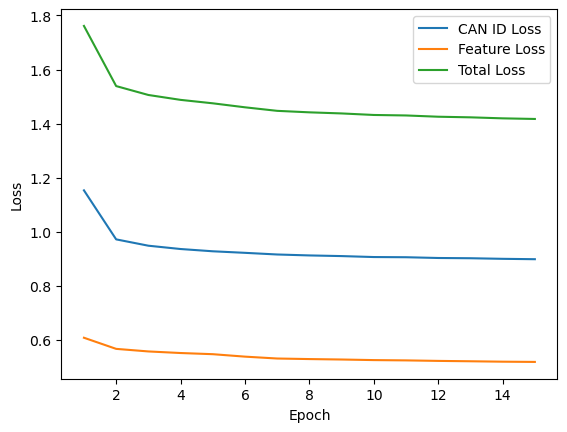

In [44]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.plot(epochs, epoch_can_id_loss, label="CAN ID Loss")
plt.plot(epochs, epoch_feature_loss, label="Feature Loss")
plt.plot(epochs, epoch_total_loss, label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

From approximately epoch 7-10 onward, the curves begin to flatten, this means the model is reaching convergence, additional epochs would slightly improve the loss but not by much.  The stable downward trend, without significant fluctuations, indicates a stable optimisation process. 

This results represent training performance only and do not by themselves demonstrate generalisation, reconstruction performance is then evaluated on the benign test data. 

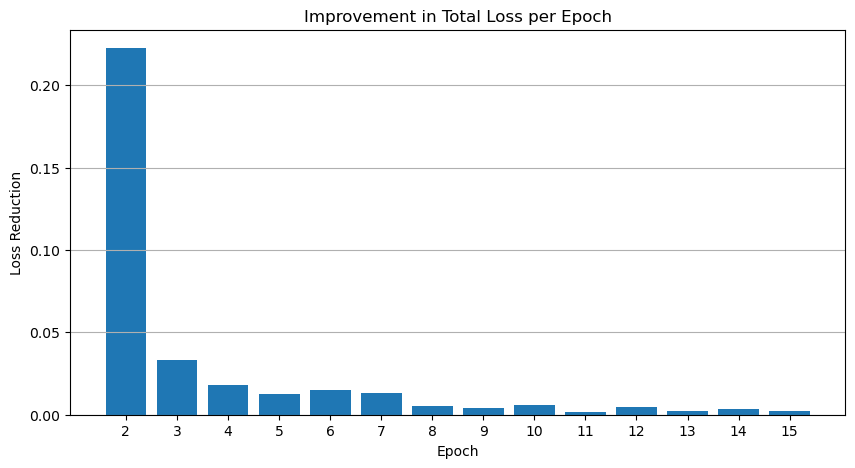

In [46]:
loss_change = []

for i in range(1, len(epoch_total_loss)):
    change = epoch_total_loss[i - 1] - epoch_total_loss[i]
    loss_change.append(change)

plt.figure(figsize=(10, 5))

plt.bar(range(2, NUM_EPOCHS + 1), loss_change)

plt.xlabel("Epoch")
plt.ylabel("Loss Reduction")
plt.title("Improvement in Total Loss per Epoch")
plt.xticks(range(2, NUM_EPOCHS + 1))
plt.grid(axis="y")

plt.show()

The loss reduction per epoch shows that most of the model's improvement happen during the early stages of training, so as we can see from epoch 1 to epoch 2, there was a big improvement since the model had to learn more about the new patterns, compared to the middle were the model already knows the main patterns and the end of training where the model is close to what it can learn with this configuration so making the model more stable towards the end.

### Testing Dataset 

In [43]:
#### Load the test data 

test_windows = []

for pt_file in test_files: 
    data = torch.load(pt_file, map_location="cpu", weights_only=False)
    test_windows.append(data["features"])
    
print("Test Files:", len(test_files))
print("First Test Tensor:", test_windows[0].shape)

Test Files: 3
First Test Tensor: torch.Size([183888, 32, 11])


In [44]:
# Test dataset and dataloader 

# store one dataset for each test file 
test_datasets = []

for file_windows in test_windows:
    test_datasets.append(BenignWindowDataset(file_windows))

test_dataset = ConcatDataset(test_datasets)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [49]:
ssl_model.eval()

test_can_loss = 0 
test_feature_loss = 0 
test_total_loss = 0 

with torch.no_grad():
    
    for can_id_batch, feature_batch in tqdm(test_loader, desc="Testing"):
        can_id_batch = can_id_batch.to(device)
        feature_batch = feature_batch.to(device)
        
        can_loss, feature_loss, total_loss = calculate_loss(can_id_batch, feature_batch)
        
        test_can_loss += can_loss.item()
        test_feature_loss += feature_loss.item()
        test_total_loss += total_loss.item()

Testing: 100%|██████████| 4471/4471 [01:29<00:00, 49.75it/s]


In [50]:
test_can_loss = test_can_loss / len(test_loader)
test_feature_loss = test_feature_loss / len(test_loader)
test_total_loss = test_total_loss / len(test_loader)

print("Test CAN ID loss:", test_can_loss)
print("Test feature loss:", test_feature_loss)
print("Test total loss:", test_total_loss)

Test CAN ID loss: 0.959542965974298
Test feature loss: 0.5278624182738225
Test total loss: 1.4874053839015045


The trained SSL model generalises well to held out benign test data, meaning that the **total reconstruction loss** **increases** only moderately from approximately **1.416 on the training data to 1.487 on the test data**, while the **numerical feature loss** remains particularly close at **0.518 compared to 0.528**. 

The CAN ID reconstruction loss shows a slighly larger increase from **0.898 to 0.960** indicating that the model needs more effort in predicting unseen masked CAN ID sequences compared to the numerical features. 

Overall, the small differences between the testing and training suggest that **the model learned transferable patterns of benign CAN behaviour rather than simply memorising the training windows.** 

#### Performance Metrics 

- CAN ID reconstruction accuracy 
- Numerical reconstruction MAE (Mean Absolute Error) measures the average size of the numerical reconstruction error. RMSE (Root Mean Squared Error) also measures reconstruction error, but penalises larger mistakes. 

Smaller MAE = predictions closer to originals 

Small RMSE = generally accurate reconstruction 

Larger RMSE > MAE = some predictsion contain relatively large errors 

Complete test window

        ↓
Hide 30% of messages

        ↓
Give masked window to trained SSL model

        ↓
Model predicts what was hidden

        ↓
Compare predictions with the original values

In [54]:
def reconstruction_metrics(data_loader):
    # Initialize CAN ID accuracy counters 
    correct = 0 
    # Total number of masked CAN IDs that the model had to reconstruct  
    total = 0 
    abs_error = 0 
    sqr_error = 0 
    total_values = 0 
    
    with torch.no_grad(): 
        for can_ids, features in data_loader: 
            can_ids = can_ids.to(device)
            features = features.to(device)
        
            # Prepare the batch for the SSL task 
            masked_ids, masked_features, mask = mask_batch(can_ids, features)
            # SSL model reconstructs the missing data 
            can_id_predictions, feature_predictions, _ = ssl_model(masked_ids, masked_features)
            # Convert the CAN ID scores into actual predictions, argmax returns the index of the highest value 
            predicted_ids = can_id_predictions.argmax(dim=2)
            
            # Update the accuracy counter 
            correct += (predicted_ids[mask] == can_ids[mask]).sum().item()
            total += mask.sum().item()
        
            # Calculate the error between the predicted and original features 
            error = feature_predictions[mask] - features[mask]
            abs_error += error.abs().sum().item()
            sqr_error += (error ** 2).sum().item()
            # Count the number of values in the error 
            total_values += error.numel()
        
    accuracy = correct / total 
    mae = abs_error / total_values 
    rmse = (sqr_error / total_values) ** 0.5
    
    return accuracy, mae, rmse 
        

In [55]:
test_accuracy, test_mae, test_rmse = reconstruction_metrics(test_loader)

print(f"CAN ID Reconstruction Accuracy: {test_accuracy * 100:.2f}%")
print(f"Numerical Reconstruction MAE: {test_mae:.4f}")
print(f"Numerical Reconstruction RMSE: {test_rmse:.4f}")

CAN ID Reconstruction Accuracy: 73.21%
Numerical Reconstruction MAE: 0.4923
Numerical Reconstruction RMSE: 0.7266


The reconstruction results indicate that the SSL model learned meaningful structure from the benign CAN traffic. CAN ID reconstruction accuracy of **73.21% means the model correctly recovers nearly three quarters of completely masked CAN IDs despite having 56 possible benign classes**, showing that it learned strong sequential relationships rather than relying on random guessing. 

**MAE of 0.4923** suggest that the **numerical predictions are on average**, about half a standard deviation away from the original standarised values, while the **higher RMSE of 0.7266 indicates that some masked messages produce larger errors.** 

Overall the model **does not reconstruct every hidden message perfectly** but it **captures enough** regularity in CAN ID order, payload, DLC and timing to justify using the learned enoder representation for the XGBoost classifier. 

### Extract Encoder Features

In [20]:
def extract_encoder(data_loader): 
    all_features = []
    
    with torch.no_grad(): 
        for can_ids, features in tqdm(data_loader, desc="Extracting features"): 
            can_ids = can_ids.to(device)
            features = features.to(device)
            
            # Runs the model on the batch on unmasked data 
            _, _, encoded_features = ssl_model(can_ids, features)
            
            # Average the features over the window size  [128,64,32] to [128,64]
            window_features = encoded_features.mean(dim=2)
            
            all_features.append(window_features.cpu())
            
    return torch.cat(all_features)

In [57]:
benign_encoder_features = extract_encoder(test_loader)

print("Encoder Feature Shape: ", benign_encoder_features.shape)

Extracting features: 100%|██████████| 4471/4471 [00:16<00:00, 279.13it/s]

Encoder Feature Shape:  torch.Size([572242, 64])


The trained SSL encoder succesfully transformed all 572,242 benign windows into 64 dimensional learned representations, producing one fixed feature vector per CAN window. 

These features no longer represent the original CAN variables directly but encode higher level combinations of CAN ID, payload, DLC, timing and sequential behaviour learned from benign traffic. 

## Multiclass Classification with XGBoost

#### Attack Window Encoder Extraction 

Given an attack window, which attack pattern does its SSL representation correspond to?

0 → DoS: CAN-ID activity + abnormal Δt / message rate

1 → Spoofing: timing + manipulated/diverse payload behaviour

2 → Fuzzing:  Random IDs: strong CAN-ID novelty | Valid IDs: timing / per-ID rate changes

3 → Replay: payload repetition + timing behaviour

```
Spoofing
├── Steering_angle_attack
├── Brake_warning_attack
├── Power_steering_attack
└── Min_speedometer_attack_1
```

```
Replay
├── EMS_replay_attack
└── Steering_angle_replay
```

```
Fuzzing
├── Fuzzing_random_IDs
└── Fuzzing_valid_IDs
```

```
DoS
└── DoS_attack
```

##### Split each attack file in chronological order before extracting its encoder features. 

This is done, because we can't use random split since the attacks where made with stride = 2, the windows overlap heavily. We need to leave 15 windows between train and test so that the last training window and first test window do not share orginal CAN messages. 


Original attack recording — chronological order

[-------------------- 70% --------------------][15-window gap][------ 30% ------]

             TRAIN                                           TEST

Check the labels stored in each attack window in order to see if the files contain benign labelled windows outside the injection interval, because we could incorrectly relabel benign windows as attacks. 

In [16]:
attack_files = sorted(ATTACK_WINDOWS.glob("*.pt"))

for pt_file in attack_files:
    # Extract the file name from the path
    file_name = pt_file.stem

    data = torch.load(pt_file, map_location="cpu", weights_only=False)

    labels = data["labels"]

    unique_labels, counts = torch.unique(labels, return_counts=True)

    print(f"File: {file_name}")
    for i in range(len(unique_labels)):
        print("Label:", unique_labels[i].item(), "Window Count:", counts[i].item())

    print()


File: Brake_warning_attack
Label: 2 Window Count: 136404

File: DoS_attack
Label: 1 Window Count: 91955

File: EMS_replay_attack
Label: 4 Window Count: 64379

File: Fuzzing_random_IDs
Label: 3 Window Count: 150525

File: Fuzzing_valid_IDs
Label: 3 Window Count: 28579

File: Min_speedometer_attack_1
Label: 2 Window Count: 146531

File: Power_steering_attack
Label: 2 Window Count: 60896

File: Steering_angle_attack
Label: 2 Window Count: 63094

File: Steering_angle_replay
Label: 4 Window Count: 101466



In [17]:
GAP_WINDOWS = 15

def split_attack_windows(file_name): 
    
    # Load the attack window files
    data = torch.load(ATTACK_WINDOWS / f"{file_name}.pt", map_location="cpu", weights_only=False)
    
    # Extract the features from the file 
    windows = data["features"]
    labels = data["labels"]
    
    # Split the windows into train and test sets based on the 70% and 30% split 
    split_index = int(len(windows) * 0.70)
    
    # Split the train window from the beginnign of the file to the split index = 70% 
    train_windows = windows[:split_index]
    train_labels = labels[:split_index]
    
    # Split the rest of the window from the split index + 15 window gap = last part of the window 
    # which corresponds to the 30% of the file 
    test_windows = windows[split_index + GAP_WINDOWS:]
    test_labels = labels[split_index + GAP_WINDOWS:]
    
    return train_windows, train_labels, test_windows, test_labels

In [18]:
# Extract the features using the same BenignWindowDataset 
# because the attack window has to have the same format as the benign windows 
def get_encoder_features(windows): 
    
    dataset = BenignWindowDataset(windows)
    
    # Create a DataLoder to iterate over the dataset in the batches 
    data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Extract the features from the dataset 
    return extract_encoder(data_loader)

#### Extract the train and test encoder features 

In [28]:
train_feature_sets = []
test_feature_sets = []

train_label_sets = []
test_label_sets = []

for file_path in attack_files:
    # Extract the file name from the path 
    file_name = file_path.stem

    # Split the attack windows into train and test sets 
    train_windows, train_window_labels, test_windows, test_window_labels = split_attack_windows(file_name)

    # Extract the encoder features 
    train_encoder_features = get_encoder_features(train_windows)
    test_encoder_features = get_encoder_features(test_windows)
    
    # Append the features and labels to the lists 
    train_feature_sets.append(train_encoder_features)
    test_feature_sets.append(test_encoder_features)

    # Convert the labels to XGBoost labels 
    # Which means that the labels are now 0–3 instead of 1–4
    train_label_sets.append(train_window_labels - 1)
    test_label_sets.append(test_window_labels - 1)

    print(file_name, "| Train:", len(train_encoder_features), "| Test:", len(test_encoder_features))

Extracting features: 100%|██████████| 320/320 [00:01<00:00, 301.69it/s]


Brake_warning_attack | Train: 95482 | Test: 40907


Extracting features: 100%|██████████| 216/216 [00:00<00:00, 301.44it/s]


DoS_attack | Train: 64368 | Test: 27572


Extracting features: 100%|██████████| 151/151 [00:00<00:00, 296.82it/s]


...

Power_steering_attack | Train: 42627 | Test: 18254


Extracting features: 100%|██████████| 148/148 [00:00<00:00, 292.50it/s]


Steering_angle_attack | Train: 44165 | Test: 18914


Extracting features: 100%|██████████| 238/238 [00:00<00:00, 293.66it/s]

Steering_angle_replay | Train: 71026 | Test: 30425


#### XGBoost datasets 

In [29]:
# Concatenate the features and labels 
X_train = torch.cat(train_feature_sets)
y_train = torch.cat(train_label_sets)

# Concatenate the test features and labels 
X_test = torch.cat(test_feature_sets)
y_test = torch.cat(test_label_sets)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([590676, 64])
y_train: torch.Size([590676])
X_test: torch.Size([253018, 64])
y_test: torch.Size([253018])


Checking the class distribution 

In [30]:
for class_id in range(4): 
    train_count = (y_train == class_id).sum().item()
    test_count = (y_test == class_id).sum().item()

    print(f"Class {class_id}: Train {train_count}, Test {test_count}")

Class 0: Train 64368, Test 27572
Class 1: Train 284845, Test 122020
Class 2: Train 125372, Test 53702
Class 3: Train 116091, Test 49724


DoS (0): 64,368 train / 27,572 test — ~11%

Spoofing (1): 284,845 / 122,020 — ~48%

Fuzzing (2): 125,372 / 53,702 — ~21%

Replay (3): 116,091 / 49,724 — ~20%

Spoofing represents almost half of the dataset, while DoS is the smallest class due to the number of files. 

This means an XGBoost model could become biased towards Spoofing if the imbalance is ignored, so overall accuracy alone would not be a reliable evaluation metric.

The chronological 70/30 split has preserved the original class distribution without artificially altering the test se

590,676 training attack windows → 64 SSL features each

253,018 test attack windows     → 64 SSL features each

#### Training Phase

In [31]:
X_train = X_train.numpy()
y_train = y_train.numpy()

X_test = X_test.numpy()
y_test = y_test.numpy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (590676, 64)
y_train: (590676,)
X_test: (253018, 64)
y_test: (253018,)


Save the dataset, due to memory restrictions because the notebook got too large, the analysis of the XGBoost classifier will be done in a separate notebook. 

In [34]:
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)

np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)